In [143]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from features import common_preprocessing, get_datasets
from utils import process_fx


In [151]:
X_input, X_primary, X_aux, Y_train = get_datasets()
target_pairs = pd.read_csv("data/target_pairs.csv")


Dropping columns:  ['US_Stock_GOLD_adj_open', 'US_Stock_GOLD_adj_high', 'US_Stock_GOLD_adj_low', 'US_Stock_GOLD_adj_close', 'US_Stock_GOLD_adj_volume', 'JPX_Gold_Mini_Futures_settlement_price', 'JPX_Gold_Rolling-Spot_Futures_settlement_price', 'JPX_Platinum_Mini_Futures_settlement_price', 'JPX_RSS3_Rubber_Futures_settlement_price']
Found 505 relevant columns
Only close column provided for stem lme_ah
Only close column provided for stem lme_ca
Only close column provided for stem lme_pb
Only close column provided for stem lme_zs


In [152]:
print(X_input.shape)
print(X_primary.shape)
print(X_aux.shape)
print(Y_train.shape)
print(target_pairs.shape)


(1871, 608)
(1871, 103)
(1871, 501)
(1871, 425)
(424, 3)


In [ ]:
Y_train.describe()


,date_id,target_0,target_1,target_2,target_3,target_4,target_5,target_6,target_7,target_8,...,target_414,target_415,target_416,target_417,target_418,target_419,target_420,target_421,target_422,target_423
count,1871.000000,1743.000000,1703.000000,1790.000000,1790.000000,1599.000000,1599.000000,1790.000000,1703.000000,1553.000000,...,1544.000000,1775.000000,1688.000000,1662.000000,1775.000000,1775.000000,1544.000000,1688.000000,1662.000000,1688.000000
mean,1025.000000,0.000479,-0.000533,0.000207,0.000122,-0.000414,-0.000131,-0.000147,-0.000501,-0.000322,...,0.002348,0.000084,-0.001059,0.000953,-0.000389,-0.000766,0.001124,0.001529,0.002186,-0.003096
std,540.255495,0.011990,0.017004,0.013150,0.014635,0.014710,0.020815,0.015371,0.017981,0.015042,...,0.019608,0.024351,0.025345,0.034143,0.031154,0.025183,0.028803,0.031790,0.030997,0.054564
min,90.000000,-0.123763,-0.120442,-0.067288,-0.072471,-0.081326,-0.099661,-0.060802,-0.105431,-0.117736,...,-0.098259,-0.127525,-0.124180,-0.293606,-0.151976,-0.148810,-0.129016,-0.180501,-0.222898,-0.212359
25%,557.500000,-0.004608,-0.010329,-0.007666,-0.008695,-0.009369,-0.012930,-0.009150,-0.011527,-0.008350,...,-0.009061,-0.015735,-0.015628,-0.016873,-0.019911,-0.015272,-0.014985,-0.015045,-0.014780,-0.033297
50%,1025.000000,0.000925,-0.000841,0.000342,0.000250,-0.000481,0.000074,0.000127,-0.000575,-0.000256,...,0.002631,-0.001176,-0.001249,0.001613,-0.000294,-0.000144,0.000588,0.002737,0.001223,-0.001912
75%,1492.500000,0.006214,0.008973,0.008872,0.008901,0.008000,0.012372,0.009171,0.009874,0.007960,...,0.013773,0.015343,0.013975,0.019844,0.019236,0.014455,0.017067,0.019550,0.018801,0.028809
max,1960.000000,0.087470,0.113968,0.047769,0.052925,0.060252,0.132583,0.096902,0.084103,0.106454,...,0.078858,0.088502,0.084397,0.181854,0.122146,0.125187,0.272182,0.187150,0.145098,0.244952


In [147]:
X_train.describe()


,date_id,dom,dow,lme_ah_weighted_close,lme_ca_weighted_close,lme_pb_weighted_close,lme_zs_weighted_close,jpx_gold_mini_futures_volume,jpx_gold_mini_futures_openinterest,jpx_gold_mini_futures_weighted_close,...,us_stock_xom_adj_intraday_volatility,us_stock_xom_adj_overnight_return,us_stock_xom_adj_day_return,us_stock_xom_adj_close_in_range,us_stock_yinn_adj_volume,us_stock_yinn_adj_weighted_close,us_stock_yinn_adj_intraday_volatility,us_stock_yinn_adj_overnight_return,us_stock_yinn_adj_day_return,us_stock_yinn_adj_close_in_range
count,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,...,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000,1871.000000
mean,1025.000000,15.771780,2.996259,0.013896,0.108220,-0.036382,0.029052,0.044518,0.050581,0.599495,...,-0.032764,0.003920,-0.011333,0.004046,0.127770,-0.227691,-0.054613,0.004010,-0.000803,-0.001715
std,540.255495,8.760618,1.412127,1.022772,1.066370,0.967860,1.055185,1.050726,1.004208,0.945377,...,0.984798,1.038475,1.034845,0.903698,1.031183,1.014393,0.960079,1.021245,1.027467,0.909747
min,90.000000,1.000000,1.000000,-3.000000,-3.000000,-2.906678,-2.815181,-3.000000,-3.000000,-3.000000,...,-1.568105,-3.000000,-3.000000,-1.705801,-2.805249,-3.000000,-1.363341,-3.000000,-3.000000,-2.013680
25%,557.500000,8.000000,2.000000,-0.706258,-0.609159,-0.752473,-0.712946,-0.639081,-0.411078,0.050357,...,-0.702317,-0.542250,-0.639425,-0.817384,-0.600991,-0.889653,-0.656554,-0.608953,-0.611484,-0.810745
50%,1025.000000,16.000000,3.000000,0.006328,0.164984,-0.093316,0.039728,-0.021293,0.279265,0.613244,...,-0.310197,0.033661,-0.020943,-0.020831,0.086523,-0.328984,-0.369581,0.006837,0.013326,0.039186
75%,1492.500000,23.000000,4.000000,0.765341,0.861179,0.757676,0.723075,0.661416,0.744769,1.122342,...,0.275125,0.628807,0.669631,0.849692,0.792842,0.318629,0.174782,0.640759,0.610756,0.821673
max,1960.000000,31.000000,5.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.055844,3.000000,...,3.000000,3.000000,3.000000,1.727719,3.000000,3.000000,3.000000,3.000000,3.000000,1.748773


6
['jpx_gold_mini_futures_openinterest', 'jpx_gold_rolling-spot_futures_openinterest', 'jpx_gold_standard_futures_openinterest', 'jpx_platinum_mini_futures_openinterest', 'jpx_platinum_standard_futures_openinterest', 'jpx_rss3_rubber_futures_openinterest']


/Users/mike/.pyenv/versions/3.12.5/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


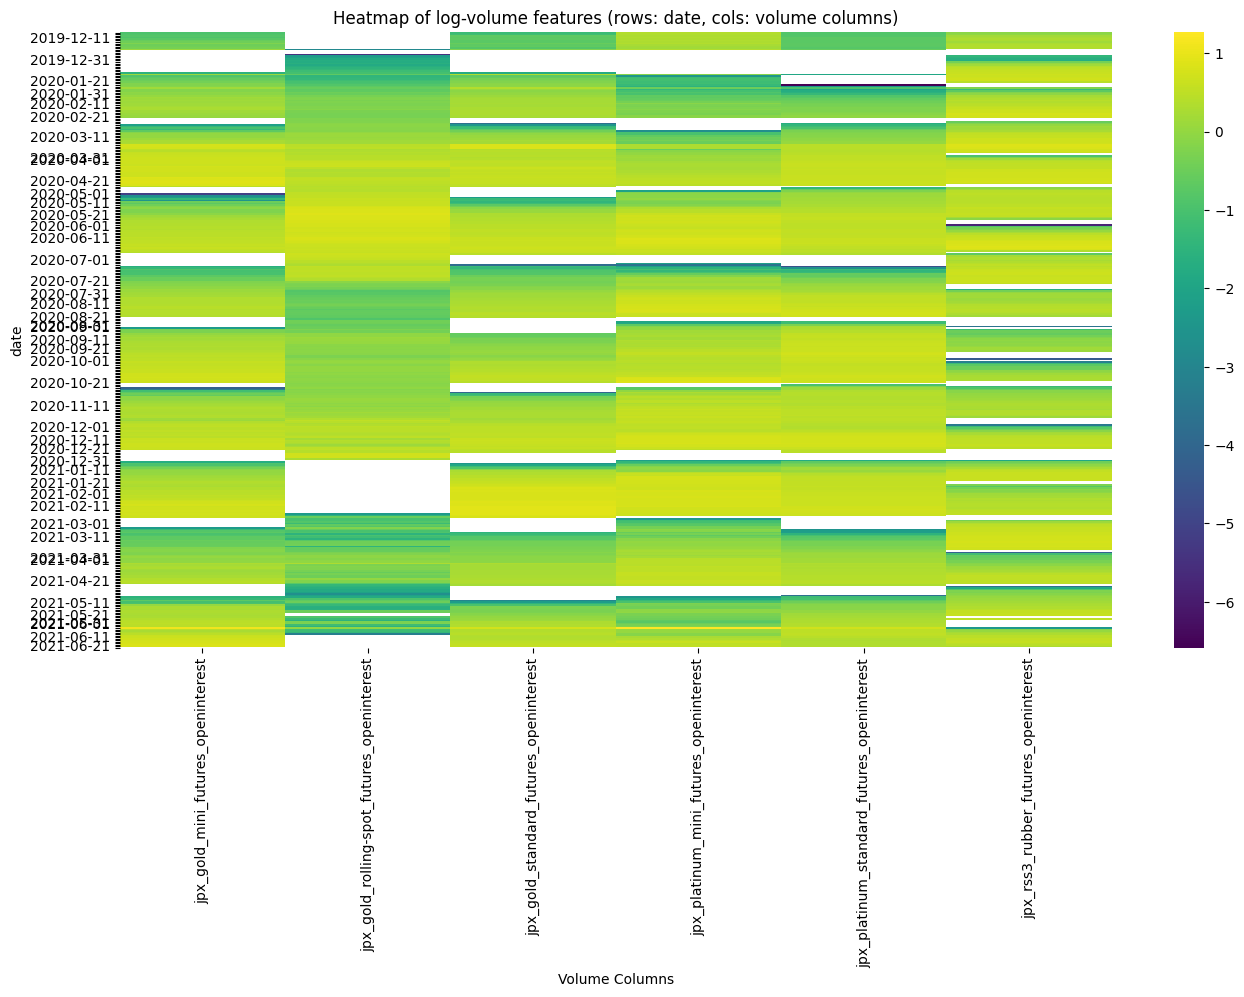

In [142]:
volume_cols = [col for col in X_train.columns if "interest" in col.lower()]
print(len(volume_cols))
print(volume_cols)
voldf = X_train[volume_cols].copy()
voldf = voldf[500:900]
log_volume = np.log1p(voldf)
date_labels = X_train.loc[500:900, "date"].tolist()

# Downsample date labels: show only every 10th label, rest as empty string
sparsified_labels = [
    date_labels[i] if date_labels[i].endswith("1") else ""
    for i in range(len(date_labels))
]

r = 0.2
# diff_log_volume = np.diff(log_volume, axis=0)
# log_volume = np.where(np.abs(diff_log_volume) > r, 0, diff_log_volume)
# log_volume = np.clip(diff_log_volume, -r, r)
plt.figure(figsize=(16, 8))
sns.heatmap(log_volume, cmap="viridis", cbar=True, yticklabels=sparsified_labels)
plt.xlabel("Volume Columns")
plt.ylabel("date")
plt.title("Heatmap of log-volume features (rows: date, cols: volume columns)")
plt.show()


In [5]:
fx_cols = [col for col in X_train.columns if "FX_" in col]
fx_df = X_train[fx_cols]
fx_df.head()


,FX_AUDJPY,FX_AUDUSD,FX_CADJPY,FX_CHFJPY,FX_EURAUD,FX_EURGBP,FX_EURJPY,FX_EURUSD,FX_GBPAUD,FX_GBPJPY,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
0,87.933498,0.783393,89.764583,115.545884,1.540368,0.887622,135.449910,1.206713,1.735387,152.598635,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,88.130730,0.782779,89.731507,115.235160,1.534906,0.889248,135.272384,1.201492,1.726072,152.119947,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,88.709278,0.786472,90.306741,115.750255,1.535084,0.890830,136.176212,1.207300,1.723206,152.864365,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037
3,88.971278,0.787461,91.079905,115.976719,1.527972,0.886809,135.945666,1.203219,1.723001,153.297609,...,1.683111,0.785329,0.889439,0.698502,0.067639,0.091558,0.121021,0.079285,14.035571,0.059983
4,88.797150,0.784808,91.136460,115.763578,1.525623,0.882271,135.471018,1.197322,1.729201,153.548140,...,1.684816,0.787264,0.891042,0.701485,0.067443,0.091266,0.121055,0.078925,14.013760,0.059503


In [6]:
res = process_fx(X_train, return_residuals=True)
res.head()


,FXL_AUD,FXL_CAD,FXL_CHF,FXL_EUR,FXL_GBP,FXL_JPY,FXL_NOK,FXL_NZD,FXL_USD,FXL_ZAR,...,FXR_GBPCAD,FXR_CADCHF,FXR_NZDCAD,FXR_NZDCHF,FXR_ZAREUR,FXR_NOKGBP,FXR_NOKCHF,FXR_ZARCHF,FXR_NOKJPY,FXR_ZARGBP
0,0.718005,0.738615,0.991092,1.150026,1.269236,-3.758575,-1.132260,0.619961,0.962126,-1.558227,...,-9.415284e-08,-4.523558e-07,-2.266560e-07,1.145051e-07,-0.000002,-0.000004,-1.488565e-07,1.685541e-06,-4.539837e-07,3.978728e-06
1,0.718966,0.736967,0.987119,1.147435,1.264814,-3.759856,-1.128820,0.619857,0.963870,-1.550352,...,8.497290e-08,4.387106e-07,-2.039292e-07,-1.908669e-07,-0.000005,-0.000003,2.994862e-07,-6.722462e-07,3.959482e-07,3.683479e-06
2,0.719876,0.737723,0.985946,1.148461,1.264062,-3.765489,-1.127598,0.625679,0.960075,-1.548735,...,6.341531e-07,-1.057419e-07,-3.922412e-07,3.554431e-07,-0.000003,0.000003,-2.310790e-07,2.749512e-07,4.709554e-08,2.744048e-06
3,0.720295,0.743718,0.985371,1.144237,1.264362,-3.768019,-1.126423,0.626554,0.959236,-1.549332,...,1.496282e-07,3.209336e-08,8.855081e-09,-3.032610e-07,-0.000002,0.000002,2.296086e-06,-3.482358e-06,-1.368404e-06,-1.050118e-07
4,0.719252,0.745255,0.984447,1.141655,1.266912,-3.767103,-1.127062,0.629891,0.961568,-1.554815,...,-2.552215e-07,-1.787910e-07,2.062908e-07,-3.846087e-07,-0.000002,-0.000003,-1.144293e-06,4.697464e-06,-6.628804e-07,-1.448226e-06


In [7]:
fxr_cols = [col for col in res.columns if "FXR_" in col]
fxr_df = res[fxr_cols]
fxr_df.max().max()


np.float64(1.2273913781335466e-05)

In [8]:
res.shape


(1961, 48)

In [9]:
fx_pairs = [(col[3:6], col[6:9]) for col in X_train.columns if "FX_" in col]
fx_set = set(elem for pair in fx_pairs for elem in pair)
fx_set


{'AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'NZD', 'USD', 'ZAR'}

In [104]:
cols = [
    f"{stem}_{suffix}"
    for stem in ["JPX_Gold_Mini_Futures"]
    for suffix in ["Open", "High", "Low", "Close", "settlement_price"]
]
close = X_train["JPX_Gold_Mini_Futures_Close"]
v = X_train[cols]
v = v.sub(close, axis=0)
v.describe()


,JPX_Gold_Mini_Futures_Open,JPX_Gold_Mini_Futures_High,JPX_Gold_Mini_Futures_Low,JPX_Gold_Mini_Futures_Close,JPX_Gold_Mini_Futures_settlement_price
count,1961.000000,1961.000000,1961.000000,1961.0,1961.000000
mean,-0.000590,0.005238,-0.006266,0.0,0.000051
std,0.008163,0.005655,0.005530,0.0,0.000465
min,-0.054147,0.000000,-0.057571,0.0,-0.003431
25%,-0.005024,0.001551,-0.008470,0.0,-0.000217
50%,-0.000869,0.003618,-0.004884,0.0,0.000000
75%,0.003410,0.007044,-0.002336,0.0,0.000308
max,0.066575,0.067714,0.000000,0.0,0.003492


In [10]:
from collections import defaultdict

categories = {
    "Open": "open",
    "adj_open": "open",
    "Close": "close",
    "adj_close": "close",
    "High": "high",
    "adj_high": "high",
    "Low": "low",
    "adj_low": "low",
    "open_interest": "open_interest",
    "Volume": "volume",
    "adj_volume": "volume",
    "settlement_price": "settlement_price",
}
by_stem = defaultdict(dict)
for col in X_train.columns:
    if "FX" in col or col == "date_id":
        continue
    entry, curr_cat = next(
        ((cat, categories[cat]) for cat in categories if cat in col), (None, None)
    )
    if not entry:
        print("can't parse", col)
    stem = col.replace(entry, "").strip("_")
    by_stem[stem][curr_cat] = col

for stem, cats in by_stem.items():
    print(stem, cats)


LME_AH {'close': 'LME_AH_Close'}
LME_CA {'close': 'LME_CA_Close'}
LME_PB {'close': 'LME_PB_Close'}
LME_ZS {'close': 'LME_ZS_Close'}
JPX_Gold_Mini_Futures {'open': 'JPX_Gold_Mini_Futures_Open', 'high': 'JPX_Gold_Mini_Futures_High', 'low': 'JPX_Gold_Mini_Futures_Low', 'close': 'JPX_Gold_Mini_Futures_Close', 'volume': 'JPX_Gold_Mini_Futures_Volume', 'settlement_price': 'JPX_Gold_Mini_Futures_settlement_price', 'open_interest': 'JPX_Gold_Mini_Futures_open_interest'}
JPX_Gold_Rolling-Spot_Futures {'open': 'JPX_Gold_Rolling-Spot_Futures_Open', 'high': 'JPX_Gold_Rolling-Spot_Futures_High', 'low': 'JPX_Gold_Rolling-Spot_Futures_Low', 'close': 'JPX_Gold_Rolling-Spot_Futures_Close', 'volume': 'JPX_Gold_Rolling-Spot_Futures_Volume', 'settlement_price': 'JPX_Gold_Rolling-Spot_Futures_settlement_price', 'open_interest': 'JPX_Gold_Rolling-Spot_Futures_open_interest'}
JPX_Gold_Standard_Futures {'open': 'JPX_Gold_Standard_Futures_Open', 'high': 'JPX_Gold_Standard_Futures_High', 'low': 'JPX_Gold_Standa

In [11]:
from utils import pca_find


In [12]:
for stem in by_stem:
    needed_cols = ["low", "high", "open", "close"]
    if not all(col in by_stem[stem] for col in needed_cols):
        continue
    cols = [by_stem[stem][col] for col in needed_cols]
    print(cols)
    res = pca_find(*[np.log(X_train[col]) for col in cols])
    print(stem, res)


['JPX_Gold_Mini_Futures_Low', 'JPX_Gold_Mini_Futures_High', 'JPX_Gold_Mini_Futures_Open', 'JPX_Gold_Mini_Futures_Close']
JPX_Gold_Mini_Futures [ 0.74201285  0.84047332 -0.58253386]
['JPX_Gold_Rolling-Spot_Futures_Low', 'JPX_Gold_Rolling-Spot_Futures_High', 'JPX_Gold_Rolling-Spot_Futures_Open', 'JPX_Gold_Rolling-Spot_Futures_Close']
JPX_Gold_Rolling-Spot_Futures [ 0.76792504  0.75741258 -0.52537705]
['JPX_Gold_Standard_Futures_Low', 'JPX_Gold_Standard_Futures_High', 'JPX_Gold_Standard_Futures_Open', 'JPX_Gold_Standard_Futures_Close']
JPX_Gold_Standard_Futures [ 0.74415611  0.84102842 -0.58523253]
['JPX_Platinum_Mini_Futures_Low', 'JPX_Platinum_Mini_Futures_High', 'JPX_Platinum_Mini_Futures_Open', 'JPX_Platinum_Mini_Futures_Close']
JPX_Platinum_Mini_Futures [ 0.69355295  0.86482947 -0.55893693]
['JPX_Platinum_Standard_Futures_Low', 'JPX_Platinum_Standard_Futures_High', 'JPX_Platinum_Standard_Futures_Open', 'JPX_Platinum_Standard_Futures_Close']
JPX_Platinum_Standard_Futures [ 0.65870899 

AssertionError: 

In [ ]:
print(target_pairs[["lag", "pair"]].to_string(max_rows=None))


     lag                                                           pair
0      1                                          US_Stock_VT_adj_close
1      1                           LME_PB_Close - US_Stock_VT_adj_close
2      1                                    LME_CA_Close - LME_ZS_Close
3      1                                    LME_AH_Close - LME_ZS_Close
4      1                 LME_AH_Close - JPX_Gold_Standard_Futures_Close
5      1             LME_ZS_Close - JPX_Platinum_Standard_Futures_Close
6      1                                    LME_PB_Close - LME_AH_Close
7      1                          LME_ZS_Close - US_Stock_VYM_adj_close
8      1      US_Stock_IEMG_adj_close - JPX_Gold_Standard_Futures_Close
9      1                                       FX_AUDJPY - LME_PB_Close
10     1  JPX_Platinum_Standard_Futures_Close - US_Stock_VGIT_adj_close
11     1                                       FX_EURAUD - LME_CA_Close
12     1                JPX_Platinum_Standard_Futures_Close - FX

In [ ]:
np.log(X_train["LME_PB_Close"] / X_train["US_Stock_VT_adj_close"]).diff()[-5:]


1956    0.019426
1957   -0.000225
1958   -0.004500
1959   -0.001036
1960   -0.002032
dtype: float64

In [ ]:
Y_train["target_1"][-5:]


1956   -0.004500
1957   -0.001036
1958   -0.002032
1959   -0.006335
1960    0.006502
Name: target_1, dtype: float64